# Predicting student performance (`score`): from data to final predictions

**Task.** Predict `score` for the 79 students in `test.rds` using the 316 students in `train.rds`. The metric is mean squared error (MSE).

**Storyline**

| Part | Question it answers |
|---|---|
| 1. Exploratory data analysis | What does the data look like, and which variables carry signal? |
| 2. Data preprocessing | How do we turn the raw columns into model-ready features without leaking information? |
| 3. Theoretical framework | Which model families do we use, and what does each one assume? |
| 4. Model tuning and comparison | Which hyper-parameters are best *within* a framework, and which framework is best *across* frameworks? |
| 5. Final model and predictions | Which model do we submit, how good is it expected to be, and what are its predictions? |

Every number used for a decision comes from cross-validation on the training data. The test set is touched exactly once, in Part 5.

In [1]:
import warnings, time, shutil, subprocess, tempfile, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyreadr
from scipy import stats

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (GridSearchCV, KFold, RepeatedKFold, cross_validate,
                                     cross_val_predict, learning_curve)
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
SEED = 42

train = pyreadr.read_r("train.rds")[None]
test = pyreadr.read_r("test.rds")[None]
X_raw = train.drop(columns="score")
y = train["score"].to_numpy()
n = len(train)
print("train:", train.shape, "| test:", test.shape, "| missing values:", int(train.isna().sum().sum()), int(test.isna().sum().sum()))
train.head()

train: (316, 31) | test: (79, 30) | missing values: 0 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18.0,U,GT3,T,3.0,2.0,other,services,...,yes,yes,5.0,4.0,3.0,2.0,3.0,1.0,7.0,0.648402
1,GP,F,17.0,U,GT3,T,3.0,4.0,services,other,...,yes,no,4.0,4.0,5.0,1.0,3.0,5.0,16.0,1.169019
2,GP,M,17.0,U,GT3,T,2.0,3.0,other,other,...,yes,no,5.0,2.0,2.0,1.0,1.0,2.0,4.0,0.384039
3,GP,M,18.0,R,GT3,T,4.0,3.0,teacher,services,...,yes,yes,5.0,3.0,2.0,1.0,2.0,4.0,9.0,1.207493
4,GP,F,16.0,U,GT3,T,1.0,3.0,at_home,services,...,yes,yes,4.0,3.0,5.0,1.0,1.0,3.0,0.0,-1.215206


---
# 1. Exploratory data analysis

Goal: understand the target, see whether relations to the predictors are linear, and find out which variables matter on their own. These observations motivate every preprocessing choice in Part 2.

## 1.1 The target

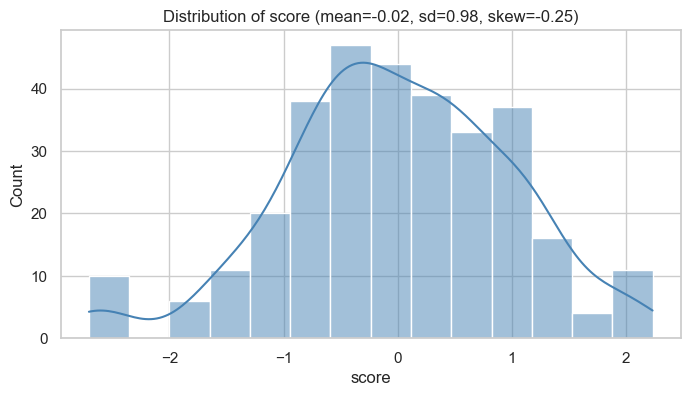

Variance of score (= MSE of always predicting the mean): 0.97


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train["score"], kde=True, ax=ax, color="steelblue")
ax.set_title(f"Distribution of score (mean={y.mean():.2f}, sd={y.std():.2f}, skew={stats.skew(y):.2f})")
plt.show()
print("Variance of score (= MSE of always predicting the mean):", round(y.var(), 3))

`score` looks standardised and roughly symmetric, so no target transformation is needed. The MSE of the "always predict the mean" baseline equals the variance of `score` (about 0.97). This is the number every model has to beat.

## 1.2 Numeric predictors: are the relations linear?

Red line = LOWESS smoother. A straight red line means a linear relation.

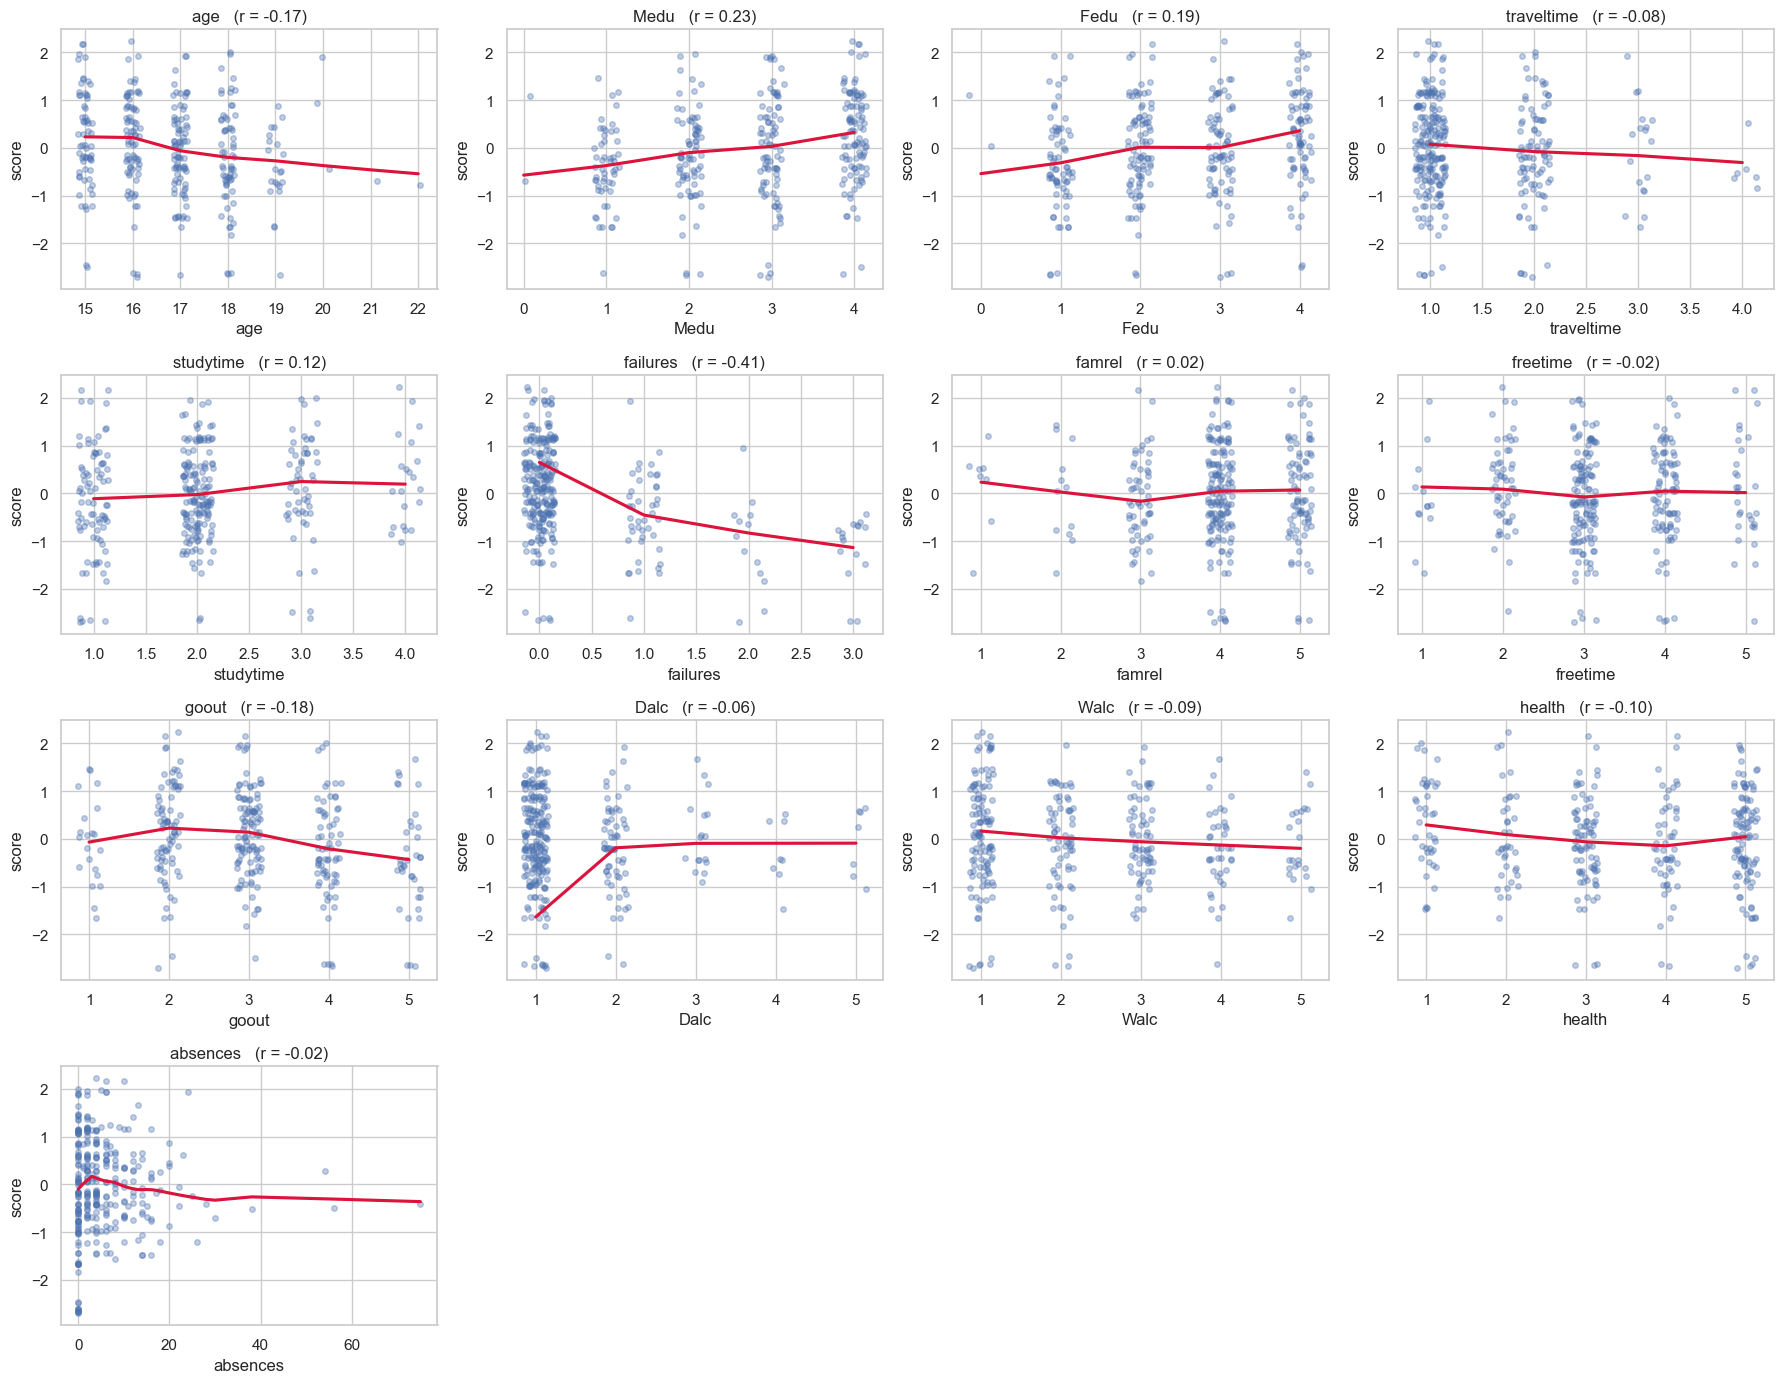

In [3]:
num_cols = X_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(4, 4, figsize=(18, 14)); axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.regplot(data=train, x=c, y="score", lowess=True, x_jitter=0.15 if train[c].nunique() <= 20 else 0,
                scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax)
    ax.set_title(f"{c}   (r = {train[c].corr(train['score']):.2f})")
for ax in axes[len(num_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 1.3 Categorical predictors

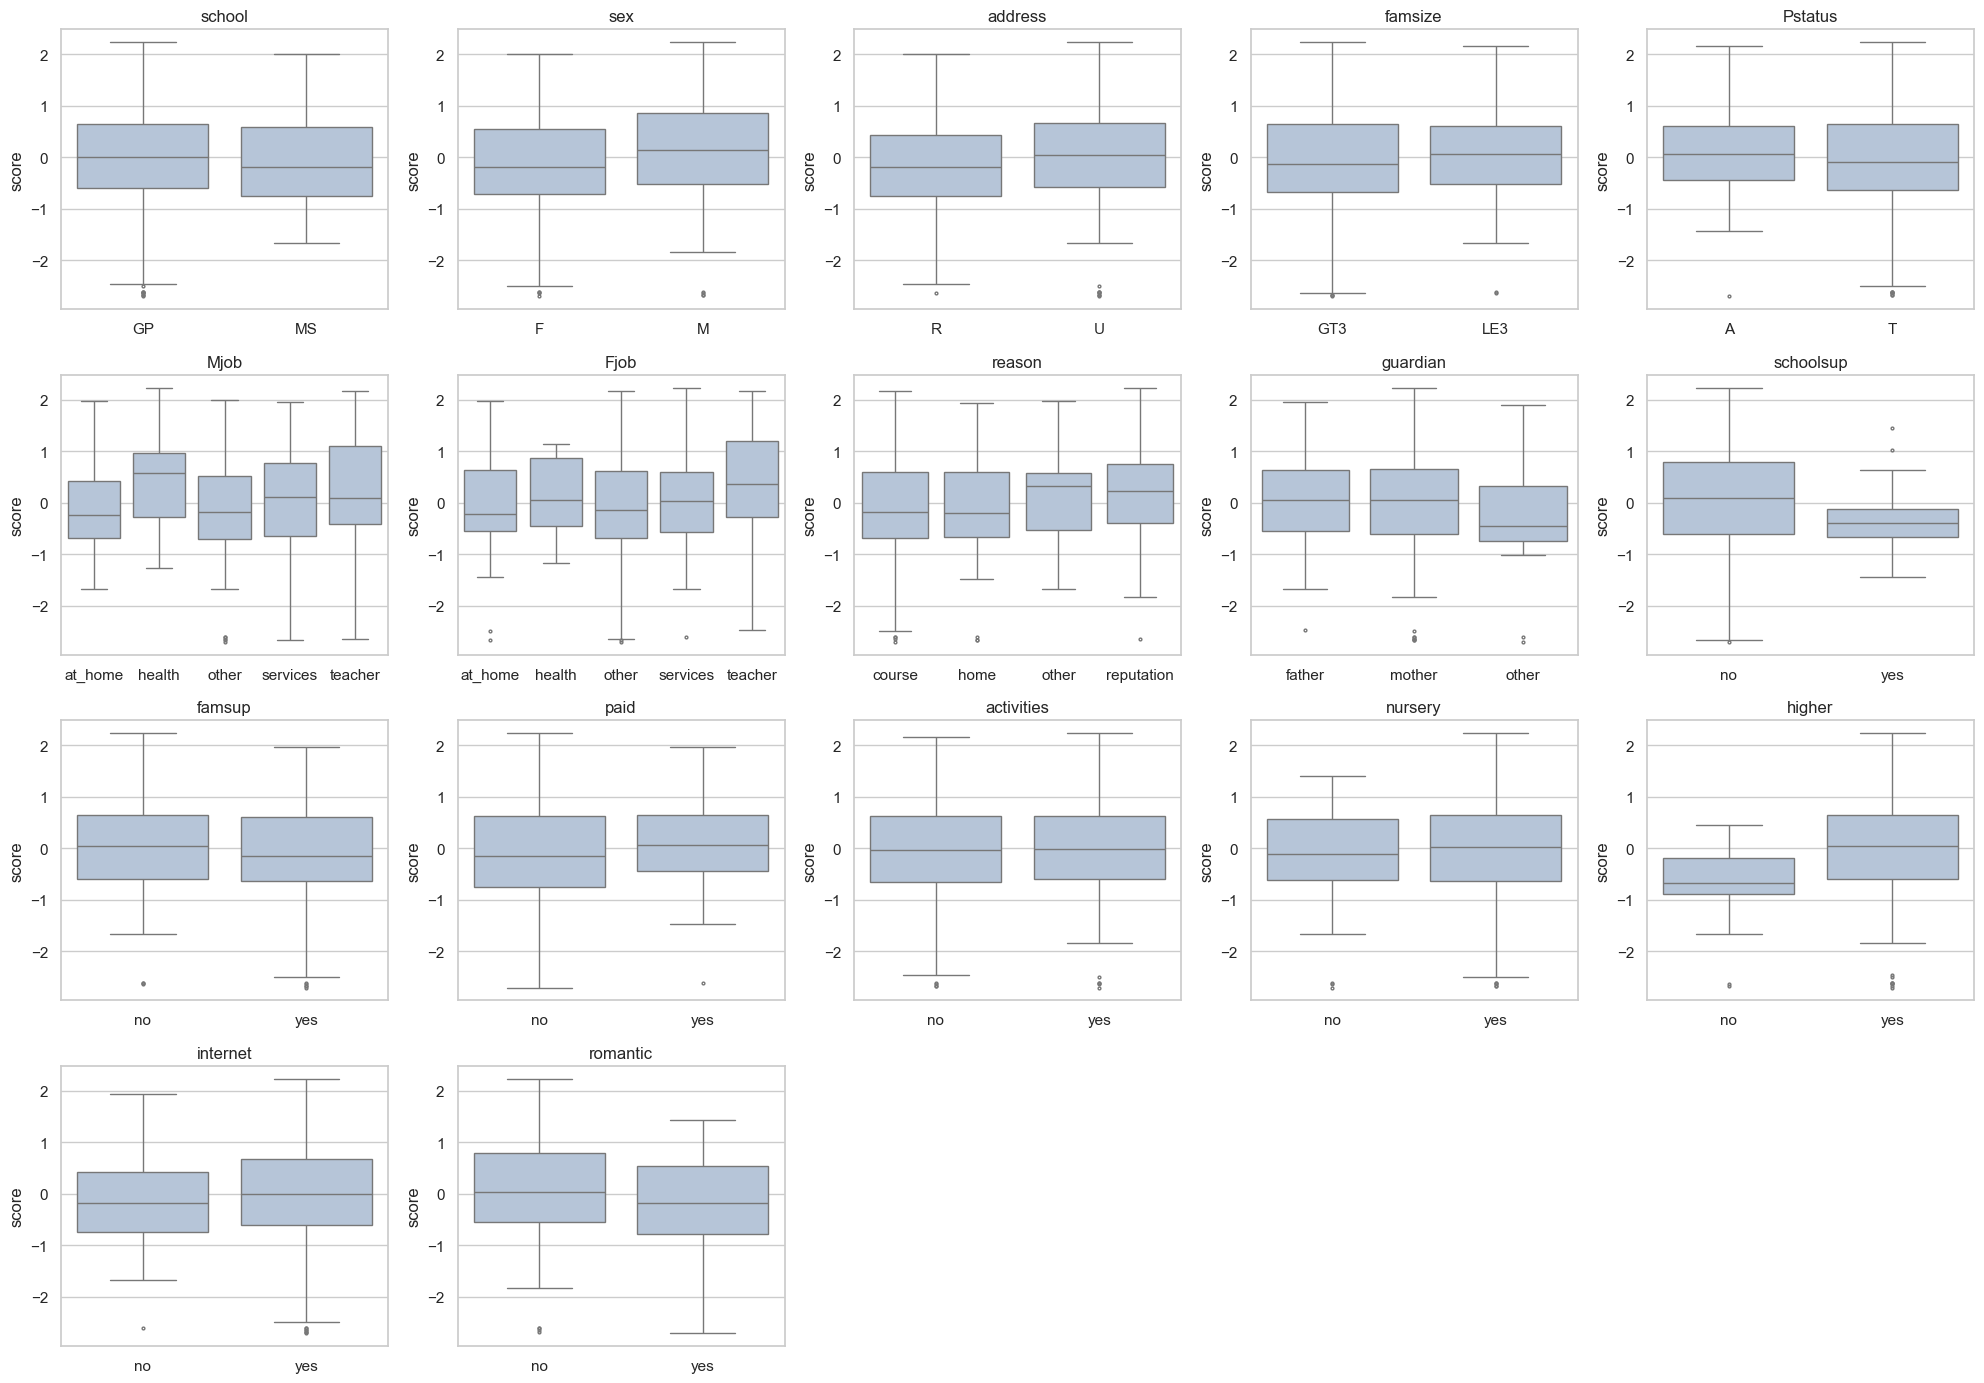

In [4]:
cat_cols = X_raw.select_dtypes("category").columns.tolist()
fig, axes = plt.subplots(4, 5, figsize=(20, 14)); axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    sns.boxplot(data=train, x=c, y="score", ax=ax, color="lightsteelblue", fliersize=2)
    ax.set_title(c); ax.set_xlabel("")
for ax in axes[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

## 1.4 Which variables matter on their own?

Univariate strength of association with `score`: R² (squared correlation) for numeric variables and η² (share of variance explained by group means) for categorical variables. Both are on the same 0 to 1 scale.

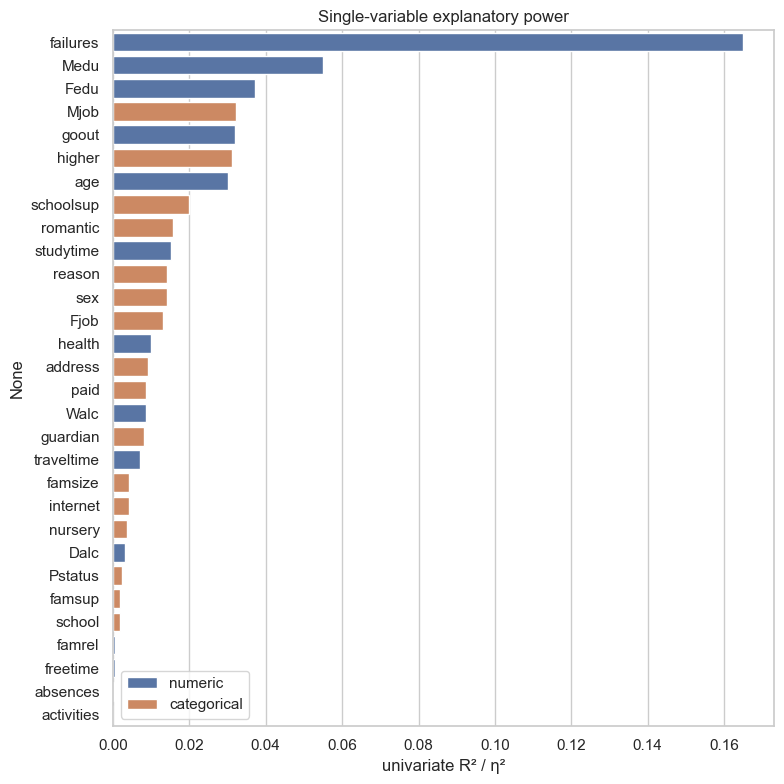

failures     0.165
Medu         0.055
Fedu         0.037
Mjob         0.032
goout        0.032
higher       0.031
age          0.030
schoolsup    0.020
Name: univariate_R2, dtype: float64

In [5]:
def eta_squared(x, yv):
    groups = [yv[(x == g).to_numpy()] for g in x.unique()]
    ss_between = sum(len(g) * (g.mean() - yv.mean()) ** 2 for g in groups)
    return ss_between / ((yv - yv.mean()) ** 2).sum()

uni = pd.Series({**{c: train[c].corr(train["score"]) ** 2 for c in num_cols},
                 **{c: eta_squared(train[c], y) for c in cat_cols}}, name="univariate_R2").sort_values(ascending=False)
kind = pd.Series({**{c: "numeric" for c in num_cols}, **{c: "categorical" for c in cat_cols}})

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=uni.values, y=uni.index, hue=kind[uni.index].values, dodge=False, ax=ax)
ax.set_xlabel("univariate R² / η²"); ax.set_title("Single-variable explanatory power")
plt.tight_layout(); plt.show()
uni.head(8).round(3)

## 1.5 Correlation between numeric predictors

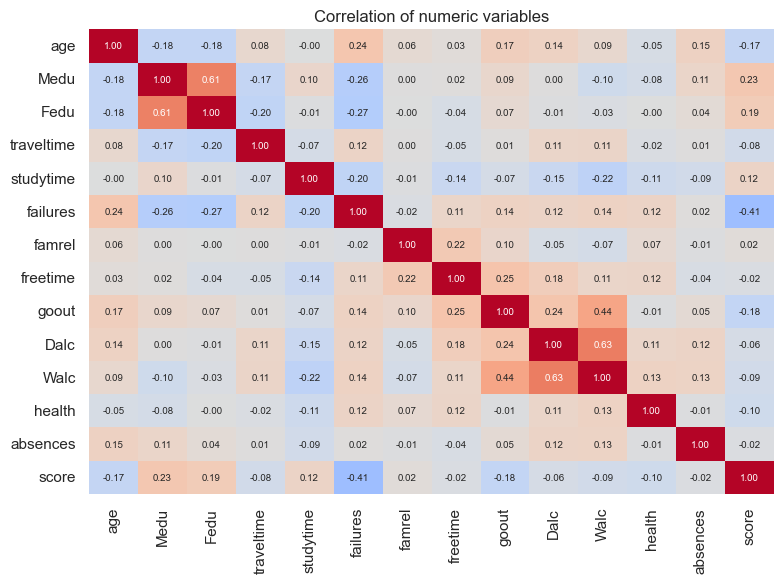

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + ["score"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws=dict(size=7), cbar=False)
plt.title("Correlation of numeric variables")
plt.tight_layout(); plt.show()

## 1.6 What the EDA tells us

* Relations are mostly **weak and roughly linear**. The strongest single signals are `failures` (clearly negative), `Medu`/`Fedu` and `Mjob` (positive), `goout` (negative), plus `higher`, `schoolsup`, `age` (read off the plots and the table above).
* `absences` is **heavily right-skewed** (many zeros, a few very large values) and shows no clear linear pattern, so it needs a transformation.
* `failures` is mostly 0 with a few large values, which suggests a **threshold effect** (any failure vs none).
* Predictors are ordinal (1 to 5) with few levels. Linear trends are plausible but not guaranteed, so non-linear models are worth testing.
* Because the signal is weak, **expect a modest R²**. The main risk is over-fitting, which favours regularised or heavily averaged models.

---
# 2. Data preprocessing

Every step below is implemented **inside the model pipeline** so that it is re-fitted on each training fold only. This prevents information from the validation fold leaking into the transformation (for example through the scaling mean).

## 2.1 The skewed predictor: `absences`

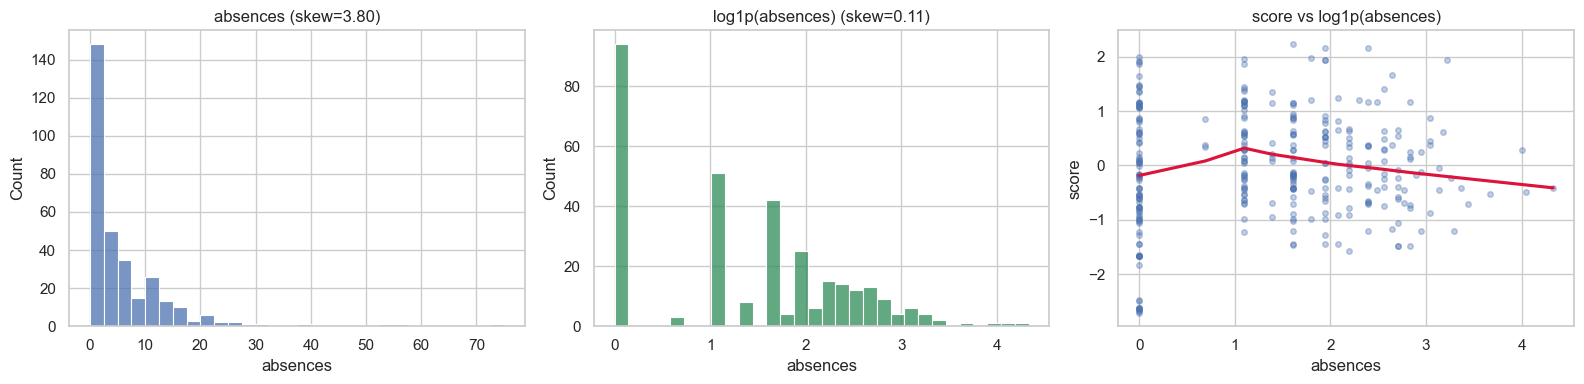

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(train["absences"], bins=30, ax=ax[0]); ax[0].set_title(f"absences (skew={stats.skew(train['absences']):.2f})")
la = np.log1p(train["absences"])
sns.histplot(la, bins=30, ax=ax[1], color="seagreen"); ax[1].set_title(f"log1p(absences) (skew={stats.skew(la):.2f})")
sns.regplot(x=la, y=train["score"], lowess=True, scatter_kws=dict(alpha=.35, s=16), line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("score vs log1p(absences)")
plt.tight_layout(); plt.show()

## 2.2 Engineered features

| Step | Why |
|---|---|
| `log_absences = log1p(absences)` and flag `no_absences` | removes the extreme skew and separates "never absent" from the rest |
| `had_failure = failures > 0` | adds the threshold effect seen in the EDA |
| `Medu_x_Fedu = Medu * Fedu` | lets the mother's and father's education interact |
| `alc_total = Dalc + Walc` | combines weekday and weekend drinking into one overall measure |

Raw `absences` is dropped after the transformation. All other raw columns are kept, so the general models can decide for themselves whether the engineered column adds anything.

In [8]:
def engineer(df):
    d = df.copy()
    d["log_absences"] = np.log1p(d["absences"])
    d["no_absences"] = (d["absences"] == 0).astype(float)
    d["had_failure"] = (d["failures"] > 0).astype(float)
    d["Medu_x_Fedu"] = d["Medu"] * d["Fedu"]
    d["alc_total"] = d["Dalc"] + d["Walc"]
    return d.drop(columns="absences")

def no_fe(df):
    return df

X_eng = engineer(X_raw)
X_eng.assign(score=y)[["log_absences", "no_absences", "had_failure", "Medu_x_Fedu", "alc_total", "score"]].describe().round(2)

,log_absences,no_absences,had_failure,Medu_x_Fedu,alc_total,score
count,316.00,316.00,316.00,316.00,316.00,316.00
mean,1.36,0.30,0.23,7.60,3.76,-0.02
std,1.06,0.46,0.42,5.23,1.96,0.99
min,0.00,0.00,0.00,0.00,2.00,-2.71
25%,0.00,0.00,0.00,3.00,2.00,-0.63
50%,1.61,0.00,0.00,6.00,3.00,-0.03
75%,2.20,1.00,0.00,12.00,5.00,0.64
max,4.33,1.00,1.00,16.00,10.00,2.23


## 2.3 Side effect: multicollinearity

The engineered columns are built from existing columns, so they are strongly correlated with their parents. This matters for plain OLS (unstable coefficients) but far less for penalised or tree models. We quantify it with the **variance inflation factor** `VIF_j = 1 / (1 - R²_j)`, where `R²_j` comes from regressing column `j` on all the other numeric columns. A common rule of thumb flags VIF above 5.

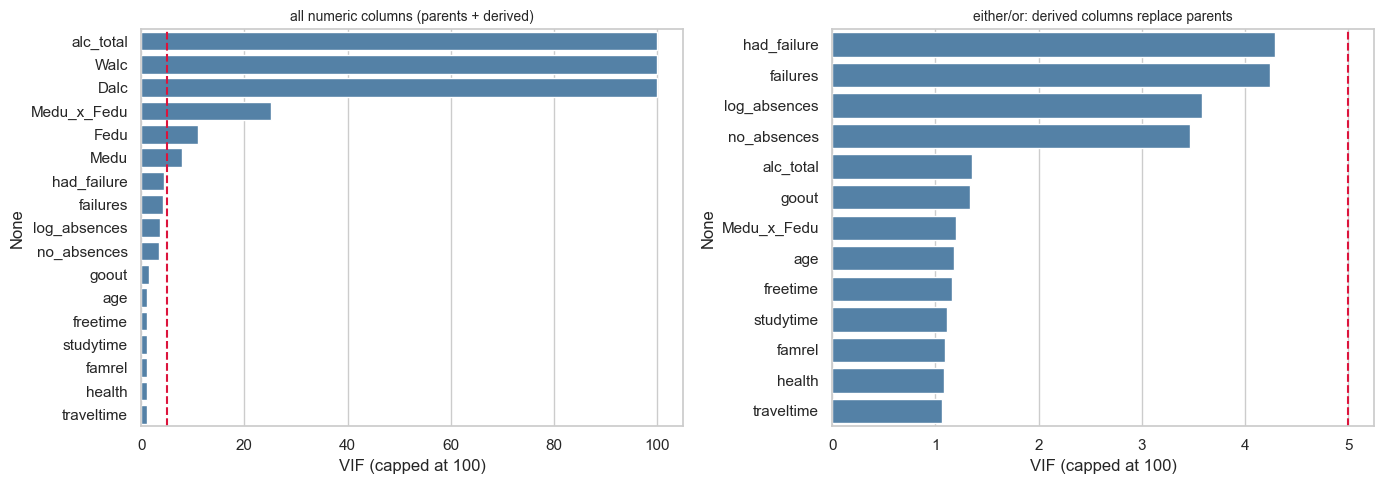

max VIF, parents + derived: 1000000.0 | max VIF, either/or: 4.3


In [9]:
def vif_table(df):
    out = {}
    for c in df.columns:
        r2 = LinearRegression().fit(df.drop(columns=c), df[c]).score(df.drop(columns=c), df[c])
        out[c] = np.inf if r2 > 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out, name="VIF").sort_values(ascending=False)

num_eng = X_eng.select_dtypes("number")
num_either_or = num_eng.drop(columns=["Medu", "Fedu", "Dalc", "Walc"])      # keep the derived feature, drop its parents

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (lab, d) in zip(ax, [("all numeric columns (parents + derived)", num_eng),
                            ("either/or: derived columns replace parents", num_either_or)]):
    v = vif_table(d).clip(upper=100)
    sns.barplot(x=v.values, y=v.index, color="steelblue", ax=a); a.axvline(5, color="crimson", ls="--")
    a.set_title(lab, fontsize=10); a.set_xlabel("VIF (capped at 100)")
plt.tight_layout(); plt.show()
print("max VIF, parents + derived:", round(vif_table(num_eng).replace(np.inf, 1e6).max(), 1),
      "| max VIF, either/or:", round(vif_table(num_either_or).max(), 1))

**Decision.** Keeping a derived feature *and* its parents creates collinearity (up to infinite VIF for exact sums such as `alc_total = Dalc + Walc`). We therefore treat the two pairs as an **either/or choice**:

* the regularised and tree-based models receive all columns, because the penalty or the tree splitting handles redundancy;
* the plain-OLS-based **hierarchical model** (Part 3.2) is given the either/or feature sets, and we test all four combinations in Part 4.

## 2.4 Encoding and scaling

| Step | Why |
|---|---|
| One-hot encoding (binary variables get 1 dummy, variables with 3+ levels one column per level; unseen levels in new data are ignored) | numeric input for the models |
| Standardisation of every column | needed for a fair Ridge/Lasso penalty and for KNN distances |

Both steps are bundled with the feature engineering in one pipeline.

In [10]:
def make_pre(fe=engineer):
    return Pipeline([
        ("fe", FunctionTransformer(fe)),
        ("ct", ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False),
              make_column_selector(dtype_include=["category", "object"]))],
            remainder="passthrough", verbose_feature_names_out=False)),
        ("sc", StandardScaler()),
    ])

pre_demo = make_pre().fit(X_raw)
feat_names = pre_demo.named_steps["ct"].get_feature_names_out()
print(len(feat_names), "model features after encoding:")
print(list(feat_names))

47 model features after encoding:
['school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'log_absences', 'no_absences', 'had_failure', 'Medu_x_Fedu', 'alc_total']


---
# 3. Theoretical framework of the models

This part only introduces the models. All fitting happens in Part 4. The candidates span four frameworks, from very rigid to very flexible, so that the comparison shows how much flexibility this data can support.

## 3.0 Two ideas that run through everything

**Bias-variance trade-off.** The expected test error of a model splits into `bias² + variance + irreducible noise`. Rigid models (high bias) miss structure; flexible models (high variance) fit noise. With only 316 rows and weak signal, variance is the main enemy, so tuning is about choosing the *right amount of flexibility*.

**Hyper-parameters and nested cross-validation.** Hyper-parameters (penalty strength, `k`, tree depth, ...) are not learned by fitting and must be chosen by validation. If the same folds both choose and evaluate them, the reported error is optimistic. **Nested CV** fixes this: an *inner* CV loop picks the hyper-parameters, an *outer* loop scores the whole procedure on data never used for tuning.

## 3.1 Baseline and linear framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **Mean baseline** | predict the training mean for everyone | none |
| **OLS** | $\hat y = \beta_0 + \sum_j \beta_j x_j$, with $\beta$ minimising $\sum_i (y_i-\hat y_i)^2$. Unbiased but high-variance when predictors are many or correlated | none |
| **Ridge** | OLS + $\alpha\sum_j\beta_j^2$ (L2 penalty). Shrinks all coefficients smoothly and handles collinearity | $\alpha$ |
| **Lasso** | OLS + $\alpha\sum_j\lvert\beta_j\rvert$ (L1 penalty). Shrinks and sets some coefficients exactly to zero (variable selection) | $\alpha$ |
| **Elastic Net** | mix of both penalties, $\alpha[\rho\lVert\beta\rVert_1 + (1-\rho)\lVert\beta\rVert_2^2/2]$ | $\alpha$, $\rho$ (`l1_ratio`) |

## 3.2 Hierarchical (theme-based) regression

A linear model with built-in structure. Predictors are grouped into three themes (**academic**, **family**, **lifestyle**). Stage 1 fits one OLS per theme and keeps its fitted values as a one-number summary (*proxy*) of that theme. Stage 2 fits a master OLS of `score` on the three proxies. This reduces the number of coefficients the final stage must estimate, and makes the result interpretable at theme level. It has no hyper-parameters; the design choice is which columns go in which theme (Part 4).

## 3.3 Instance-based framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **K-nearest neighbours** | predict the average `score` of the $k$ most similar students (Euclidean distance on standardised features); optionally weight neighbours by inverse distance | $k$, weighting |

No model is fitted. It suffers from the curse of dimensionality: with 46 features, "nearest" neighbours are often not very near.

## 3.4 Tree-based framework

| Model | Idea | Hyper-parameters |
|---|---|---|
| **Regression tree** | recursively split the data on the feature/threshold that most reduces squared error; predict the leaf mean. Captures interactions and non-linearity, but a single deep tree is very unstable | `max_depth`, `min_samples_leaf` |
| **Random forest** | average many trees, each grown on a bootstrap sample and using a random subset of features per split. Averaging decorrelated trees cuts variance without raising bias much | `max_features`, `min_samples_leaf` |
| **Gradient boosting** | build shallow trees *sequentially*, each one fitting the residual errors of the ensemble so far, scaled by a learning rate. Reduces bias; needs regularisation (small learning rate, shallow trees, subsampling) | `learning_rate`, `max_depth`, `n_estimators` |

## 3.5 How the frameworks compare

| Framework | Flexibility | Main risk | Expected fit for this data |
|---|---|---|---|
| Baseline | none | under-fitting | reference only |
| Linear (OLS) | low | variance from many correlated predictors | mediocre |
| Linear, penalised | low to medium | bias if over-shrunk | good when signal is weak |
| Hierarchical | low, structured | bias from the theme split | competitive, interpretable |
| KNN | medium | curse of dimensionality | poor with 46 features |
| Single tree | medium to high | instability | poor unless pruned hard |
| Forest / boosting | high, but averaged | over-fitting (boosting), cost | strongest candidates |

---
# 4. Model tuning and comparison

**Plan**

1. Set up the estimators, tuning grids and CV scheme.
2. Check that the preprocessing of Part 2 actually helps.
3. **Within each framework:** look at how the error responds to the hyper-parameters.
4. Run **nested CV** for every model on identical outer folds.
5. Compare **within** frameworks, then **across** frameworks.

## 4.0 Set-up

### The hierarchical estimator
scikit-learn has no hierarchical regression, so we define it as a custom estimator that follows the three stages of Part 3.2.

In [11]:
class HierarchicalRegressor(RegressorMixin, BaseEstimator):
    # Academic / family / lifestyle sub-models -> proxies -> master OLS.

    def __init__(self, academic_cols, family_cols, lifestyle_cols):
        self.academic_cols = academic_cols
        self.family_cols = family_cols
        self.lifestyle_cols = lifestyle_cols

    def _block_pipe(self, cols, X):
        cat = [c for c in cols if not pd.api.types.is_numeric_dtype(X[c])]
        ct = ColumnTransformer(
            [("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), cat)],
            remainder="passthrough")
        return Pipeline([("ct", ct), ("lm", LinearRegression())])

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True); y = np.asarray(y)
        self.blocks_ = {"academic": self.academic_cols, "family": self.family_cols, "lifestyle": self.lifestyle_cols}
        self.sub_pipes_ = {k: self._block_pipe(c, X).fit(X[c], y) for k, c in self.blocks_.items()}   # stage 1
        self.master_ = LinearRegression().fit(self._proxies(X), y)                                      # stage 2
        return self

    def _proxies(self, X):
        return np.column_stack([self.sub_pipes_[k].predict(X[c]) for k, c in self.blocks_.items()])

    def predict(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return self.master_.predict(self._proxies(X))


def hier_blocks(medu_fedu="raw", alc="raw"):
    # Column lists for the three themes. Never includes both a derived feature and its parents (see 2.3).
    # (`famsup`, absent from the earlier drafts' blocks, is placed in the family block.)
    academic = ["school", "reason", "studytime", "failures", "had_failure",
                "schoolsup", "paid", "higher", "log_absences", "no_absences", "traveltime"]
    family = (["Medu", "Fedu"] if medu_fedu == "raw" else ["Medu_x_Fedu"]) + \
             ["guardian", "Mjob", "Fjob", "famsize", "Pstatus", "famrel", "nursery", "famsup"]
    lifestyle = ["age", "sex", "address", "health", "romantic", "activities", "internet", "freetime", "goout"] + \
                (["Dalc", "Walc"] if alc == "raw" else ["alc_total"])
    return academic, family, lifestyle

HIER_VARIANTS = {   # 2 x 2 design: parents vs derived feature, for each pair
    "Hier. A (Medu+Fedu, Dalc+Walc)":  dict(medu_fedu="raw",         alc="raw"),
    "Hier. B (Medu×Fedu, Dalc+Walc)":  dict(medu_fedu="interaction", alc="raw"),
    "Hier. C (Medu+Fedu, alc_total)":  dict(medu_fedu="raw",         alc="combo"),
    "Hier. D (Medu×Fedu, alc_total)":  dict(medu_fedu="interaction", alc="combo"),
}
HIER_MAIN = "Hier. D (Medu×Fedu, alc_total)"   # fixed in advance: the collinearity-free, most compact variant

### Model registry, tuning grids and CV scheme

* `FRAMEWORK` tags each model with its family for the within-framework comparison.
* `inner_cv` (5-fold) chooses hyper-parameters; `outer_cv` (5-fold × 3 repeats = 15 test folds) scores the whole procedure. All models share the same outer folds, so differences between models are **paired**.

In [12]:
def pipe(model, fe=engineer):
    if isinstance(model, HierarchicalRegressor):
        return Pipeline([("fe", FunctionTransformer(fe)), ("m", model)])       # OLS blocks: no scaling needed
    return Pipeline([("pre", make_pre(fe)), ("m", model)])

BASE = "Mean (baseline)"
MODELS = {
    BASE: (DummyRegressor(), {}),
    "OLS": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"m__alpha": np.logspace(-1, 3, 30)}),
    "Lasso": (Lasso(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 30)}),
    "Elastic Net": (ElasticNet(max_iter=50000), {"m__alpha": np.logspace(-3, -0.3, 15), "m__l1_ratio": [.2, .5, .8]}),
    **{name: (HierarchicalRegressor(*hier_blocks(**flags)), {}) for name, flags in HIER_VARIANTS.items()},
    "KNN": (KNeighborsRegressor(), {"m__n_neighbors": [5, 10, 15, 20, 30, 40, 60], "m__weights": ["uniform", "distance"]}),
    "Tree": (DecisionTreeRegressor(random_state=SEED), {"m__max_depth": [2, 3, 4, 5], "m__min_samples_leaf": [5, 10, 20]}),
    "Random Forest": (RandomForestRegressor(n_estimators=300, random_state=SEED),
                      {"m__max_features": [0.2, 0.4], "m__min_samples_leaf": [3, 8]}),
    "Gradient Boosting": (GradientBoostingRegressor(subsample=0.7, random_state=SEED),
                          {"m__learning_rate": [0.01, 0.03], "m__max_depth": [1, 2], "m__n_estimators": [100, 300]}),
}
FRAMEWORK = {BASE: "Baseline", "OLS": "Linear", "Ridge": "Linear", "Lasso": "Linear", "Elastic Net": "Linear",
             **{k: "Hierarchical" for k in HIER_VARIANTS},
             "KNN": "Instance-based", "Tree": "Tree-based", "Random Forest": "Tree-based", "Gradient Boosting": "Tree-based"}

inner_cv = KFold(5, shuffle=True, random_state=SEED)
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def tuned(name, fe=engineer, cv=inner_cv):
    model, grid = MODELS[name]
    return GridSearchCV(pipe(model, fe), grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)

## 4.1 Does the preprocessing help?

Three representative models (two linear, one tree-based) are run with raw vs engineered features on the same outer folds. Note that the hierarchical model needs the engineered columns by construction, so it is left out of this test.

In [13]:
cmp = {}
for name in ["Ridge", "Lasso", "Random Forest"]:
    for lab, fe in [("raw", no_fe), ("engineered", engineer)]:
        r = cross_validate(tuned(name, fe=fe), X_raw, y, cv=outer_cv, n_jobs=-1, scoring="neg_mean_squared_error")
        cmp[(name, lab)] = -r["test_score"].mean()
cmp = pd.Series(cmp).unstack()
cmp["improvement_%"] = 100 * (cmp["raw"] - cmp["engineered"]) / cmp["raw"]
cmp.round(4)

,engineered,raw,improvement_%
Lasso,0.7870,0.8151,3.4399
Random Forest,0.7529,0.7548,0.2593
Ridge,0.7853,0.8181,4.0116


Engineering lowers the error for all three models. The gain is clearest for the penalised linear models (3 to 4 %); the forest already finds the non-linear structure by itself and gains almost nothing (0.3 %). We keep `engineer()` for all models.

## 4.2 Tuning inside each framework

For every tunable model, the plots below show the 5-fold CV MSE over its grid (fitted on the full training data, for visualisation only; the honest error estimate comes from nested CV in 4.3). The dashed line is the mean-baseline error. A good grid has its optimum **inside** the range and not on the edge.

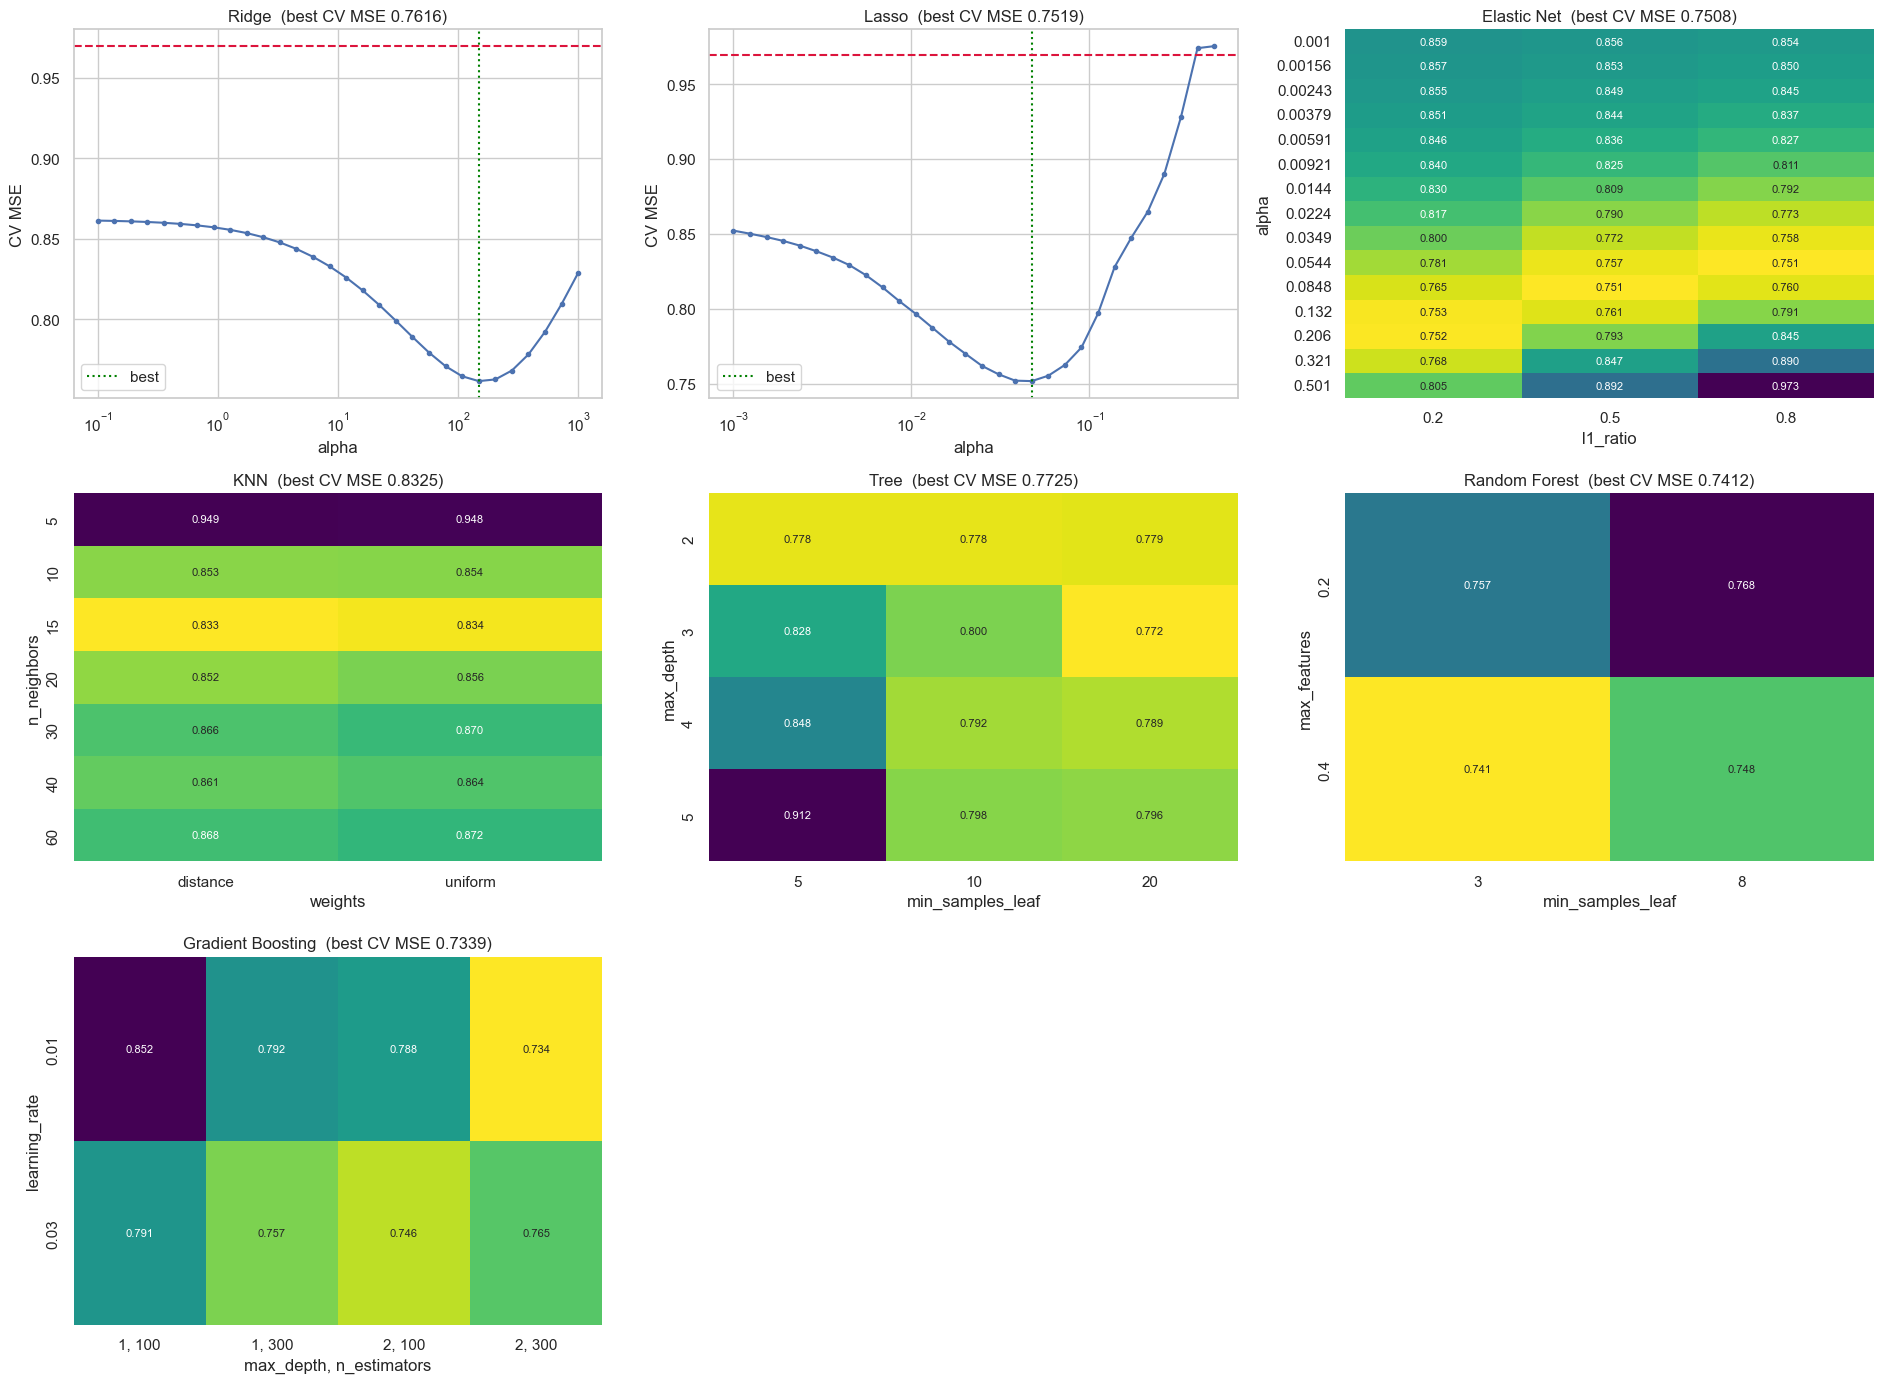

Ridge                                 {'m__alpha': 148.73521072935117}
Lasso                               {'m__alpha': 0.047409139089632936}
Elastic Net          {'m__alpha': 0.08483428982440722, 'm__l1_ratio...
KNN                   {'m__n_neighbors': 15, 'm__weights': 'distance'}
Tree                    {'m__max_depth': 3, 'm__min_samples_leaf': 20}
Random Forest        {'m__max_features': 0.4, 'm__min_samples_leaf'...
Gradient Boosting    {'m__learning_rate': 0.01, 'm__max_depth': 2, ...
dtype: object

In [14]:
def grid_results(name):
    gs = tuned(name).fit(X_raw, y)
    r = pd.DataFrame(gs.cv_results_["params"])
    r.columns = [c.replace("m__", "") for c in r.columns]
    r["mse"] = -gs.cv_results_["mean_test_score"]
    return r, gs

def show_grid(name, ax, logx=False):
    r, gs = grid_results(name)
    params = [c for c in r.columns if c != "mse"]
    if len(params) == 1:
        ax.plot(r[params[0]], r["mse"], marker="o", ms=3)
        if logx: ax.set_xscale("log")
        ax.set_xlabel(params[0]); ax.set_ylabel("CV MSE")
        ax.axvline(gs.best_params_["m__" + params[0]], color="green", ls=":", label="best")
        ax.legend()
    else:
        cols = params[1:]
        r = r.sort_values(cols)
        r["_col"] = r[cols].astype(str).agg(", ".join, axis=1)
        piv = r.pivot_table(index=params[0], columns="_col", values="mse")[r["_col"].drop_duplicates()]
        piv.index = [f"{v:.3g}" if isinstance(v, float) else v for v in piv.index]
        sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", cbar=False, ax=ax, annot_kws=dict(size=8))
        ax.set_ylabel(params[0]); ax.set_xlabel(", ".join(cols))
    ax.set_title(f"{name}  (best CV MSE {r['mse'].min():.4f})")
    return gs.best_params_

base_mse = y.var()
tuned_names = ["Ridge", "Lasso", "Elastic Net", "KNN", "Tree", "Random Forest", "Gradient Boosting"]
fig, axes = plt.subplots(3, 3, figsize=(19, 14)); axes = axes.ravel()
best_params_demo = {}
for ax, name in zip(axes, tuned_names):
    best_params_demo[name] = show_grid(name, ax, logx=name in ("Ridge", "Lasso"))
    if name in ("Ridge", "Lasso"): ax.axhline(base_mse, color="crimson", ls="--")
for ax in axes[len(tuned_names):]: ax.axis("off")
plt.tight_layout(); plt.show()
pd.Series(best_params_demo)

**Reading the curves.**

* **Ridge / Lasso / Elastic Net:** CV error falls as the penalty grows from near zero (about 0.85, almost the OLS error), reaches a minimum, then climbs towards the baseline once everything is shrunk away. This U-shape is the bias-variance trade-off made visible, and the optimum is interior (Ridge needs a very strong penalty, $\alpha\approx 150$, because the many dummy columns are mostly noise). The Elastic Net heatmap shows a ridge of near-equal optima along the diagonal: a larger `l1_ratio` needs a smaller $\alpha$.
* **KNN:** $k=5$ is far too noisy (0.95); the error is lowest around $k=15$ and rises again for larger $k$. Even at its best it stays well above the penalised models.
* **Tree:** shallow trees with large leaves are best (depth 3, 20 rows per leaf); deeper trees with small leaves over-fit sharply (0.91 at depth 5, leaf 5).
* **Random forest / boosting:** the best settings sit at the **edge** of the grid (`max_features=0.4`, `min_samples_leaf=3`; for boosting the learning rate 0.01 with depth 2 and 300 trees). A wider grid could squeeze out a little more, but the differences between cells are small compared with the fold-to-fold noise, so we keep the grid compact.
* The best CV MSEs printed here are lower than the nested-CV values in 4.3 (for example forest 0.741 vs 0.753). This gap is the optimism of choosing the best setting on the same folds that score it, and it is exactly why the nested scheme is used for the final comparison.

## 4.3 Nested cross-validation for every model

The inner 5-fold CV picks the hyper-parameters; the outer 5 × 3 CV scores the whole procedure. We also keep the training-fold error to measure over-fitting (`overfit_ratio = CV MSE / train MSE`; 1 = no over-fitting).

In [15]:
t0 = time.time()
nested = {}
for name in MODELS:
    nested[name] = cross_validate(tuned(name), X_raw, y, cv=outer_cv, n_jobs=-1, return_train_score=True,
                                  scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    print(f"{name:34s} done ({time.time() - t0:5.0f}s)  CV MSE = {-nested[name]['test_mse'].mean():.4f}")

rows = []
for name, r in nested.items():
    cv_mse, tr_mse = -r["test_mse"].mean(), -r["train_mse"].mean()
    rows.append(dict(model=name, framework=FRAMEWORK[name], CV_MSE=cv_mse, train_MSE=tr_mse,
                     fold_sd_MSE=(-r["test_mse"]).std(), CV_R2=r["test_r2"].mean(), overfit_ratio=cv_mse / tr_mse))
res = pd.DataFrame(rows).set_index("model")

Mean (baseline)                    done (    0s)  CV MSE = 0.9746


OLS                                done (    0s)  CV MSE = 0.8529


Ridge                              done (    5s)  CV MSE = 0.7853


Lasso                              done (   10s)  CV MSE = 0.7870


Elastic Net                        done (   18s)  CV MSE = 0.7858


...

Hier. D (Medu×Fedu, alc_total)     done (   19s)  CV MSE = 0.7969


KNN                                done (   22s)  CV MSE = 0.8750


Tree                               done (   25s)  CV MSE = 0.7911


Random Forest                      done (   35s)  CV MSE = 0.7529


Gradient Boosting                  done (   43s)  CV MSE = 0.7605


## 4.4 Comparison **within** each framework

Question: inside one family, does extra flexibility or structure pay off?

In [16]:
cols = ["CV_MSE", "fold_sd_MSE", "CV_R2", "train_MSE", "overfit_ratio"]
for fw in ["Linear", "Hierarchical", "Tree-based"]:
    print(f"\n=== {fw} ===")
    display(res[res["framework"] == fw].sort_values("CV_MSE")[cols].round(4))


=== Linear ===


,CV_MSE,fold_sd_MSE,CV_R2,train_MSE,overfit_ratio
model,,,,,
Ridge,0.7853,0.1526,0.1826,0.6492,1.2095
Elastic Net,0.7858,0.1529,0.1827,0.6728,1.1680
Lasso,0.7870,0.1510,0.1810,0.6780,1.1608
OLS,0.8529,0.1559,0.1079,0.5955,1.4321



=== Hierarchical ===


,CV_MSE,fold_sd_MSE,CV_R2,train_MSE,overfit_ratio
model,,,,,
"Hier. D (Medu×Fedu, alc_total)",0.7969,0.1695,0.1725,0.6454,1.2347
"Hier. C (Medu+Fedu, alc_total)",0.7976,0.1724,0.1725,0.6435,1.2395
"Hier. B (Medu×Fedu, Dalc+Walc)",0.7994,0.1694,0.1697,0.6451,1.2391
"Hier. A (Medu+Fedu, Dalc+Walc)",0.8001,0.1722,0.1696,0.6432,1.2439



=== Tree-based ===


,CV_MSE,fold_sd_MSE,CV_R2,train_MSE,overfit_ratio
model,,,,,
Random Forest,0.7529,0.1611,0.2197,0.3526,2.1352
Gradient Boosting,0.7605,0.1592,0.2111,0.5526,1.3763
Tree,0.7911,0.1653,0.1781,0.7187,1.1007


**Interpretation.**

* **Linear:** penalisation clearly beats plain OLS (0.785 to 0.787 vs 0.853); Ridge, Lasso and Elastic Net are practically indistinguishable. OLS pays a variance cost for the many dummy columns (overfit ratio 1.43).
* **Hierarchical:** the four variants A to D differ by under 0.005 in MSE, far below the fold-to-fold SD of about 0.17, so they are **not** evidence that one feature choice is better. We use variant D because it was fixed in advance (collinearity-free, Part 2.3, fewest parameters), not because it scores best.
* **Tree-based:** averaging (forest, 0.753) and sequential correction (boosting, 0.761) both improve clearly on the single tree (0.791). The forest also over-fits the training folds most (overfit ratio 2.1), yet still generalises best; in-sample fit is not a good guide to test error.

## 4.5 Comparison **across** frameworks

One representative per model is entered: hierarchical variant D (chosen a priori, not by CV score, so it carries no selection bias).

,framework,CV_MSE,fold_sd_MSE,CV_R2,train_MSE,overfit_ratio
model,,,,,,
Random Forest,Tree-based,0.7529,0.1611,0.2197,0.3526,2.1352
Gradient Boosting,Tree-based,0.7605,0.1592,0.2111,0.5526,1.3763
Ridge,Linear,0.7853,0.1526,0.1826,0.6492,1.2095
Elastic Net,Linear,0.7858,0.1529,0.1827,0.6728,1.1680
Lasso,Linear,0.7870,0.1510,0.1810,0.6780,1.1608
Tree,Tree-based,0.7911,0.1653,0.1781,0.7187,1.1007
Hierarchical,Hierarchical,0.7969,0.1695,0.1725,0.6454,1.2347
OLS,Linear,0.8529,0.1559,0.1079,0.5955,1.4321
KNN,Instance-based,0.8750,0.1600,0.0897,0.1376,6.3609


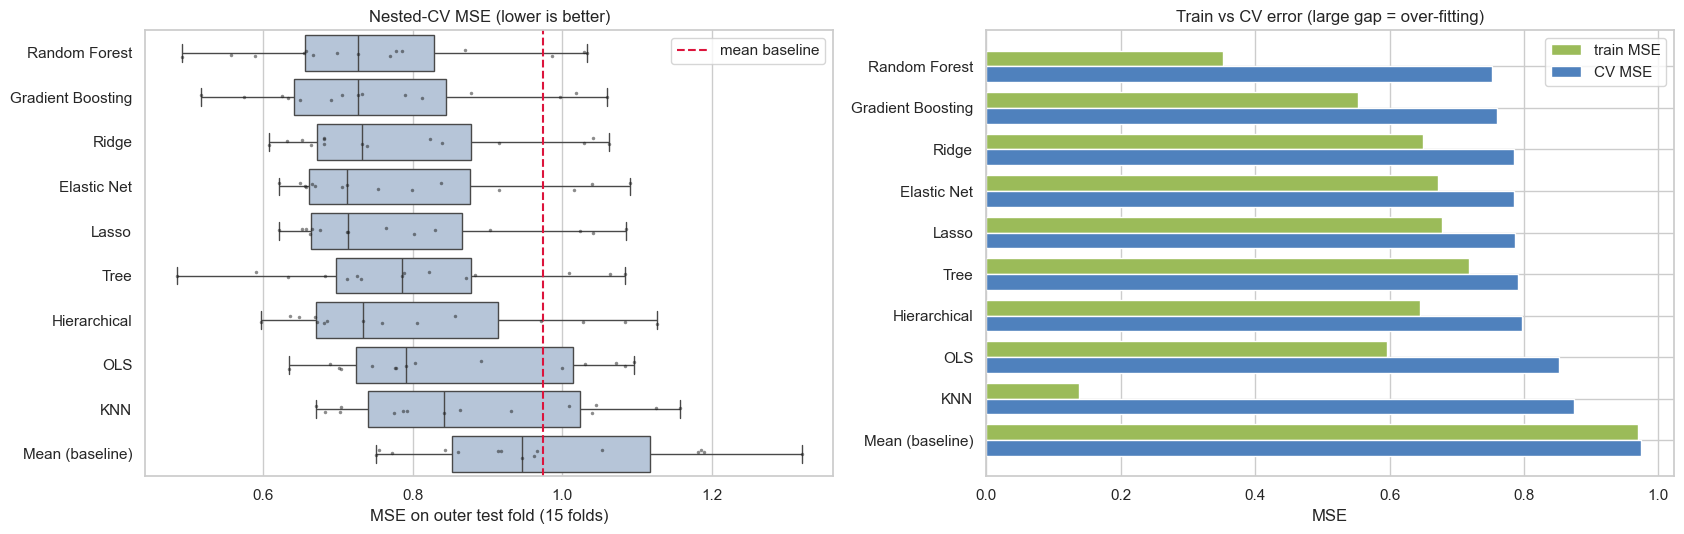

In [17]:
across = res.drop(index=[k for k in HIER_VARIANTS if k != HIER_MAIN]).rename(index={HIER_MAIN: "Hierarchical"})
across = across.sort_values("CV_MSE")
order = across.index.tolist()
display(across[["framework"] + cols].round(4))

fold_mse = pd.DataFrame({("Hierarchical" if k == HIER_MAIN else k): -nested[k]["test_mse"]
                         for k in across.index.map(lambda m: HIER_MAIN if m == "Hierarchical" else m)})[order]
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.boxplot(data=fold_mse, orient="h", ax=ax[0], color="lightsteelblue", fliersize=3)
sns.stripplot(data=fold_mse, orient="h", ax=ax[0], color="k", size=2.5, alpha=.5)
ax[0].axvline(across.loc[BASE, "CV_MSE"], color="crimson", ls="--", label="mean baseline")
ax[0].set_xlabel("MSE on outer test fold (15 folds)"); ax[0].set_title("Nested-CV MSE (lower is better)"); ax[0].legend()

w = 0.38; ypos = np.arange(len(order))
ax[1].barh(ypos - w/2, across["train_MSE"], w, label="train MSE", color="#9bbb59")
ax[1].barh(ypos + w/2, across["CV_MSE"], w, label="CV MSE", color="#4f81bd")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(order); ax[1].invert_yaxis()
ax[1].set_xlabel("MSE"); ax[1].set_title("Train vs CV error (large gap = over-fitting)"); ax[1].legend()
plt.tight_layout(); plt.show()

### Are the top models really different?

Because all models share the same outer folds, we can test the **paired** fold-by-fold difference against the best model. (Folds from repeated CV overlap, so the p-values are approximate and should be read as a rough guide only.)

In [18]:
best_name = across.index[0]
key = lambda m: HIER_MAIN if m == "Hierarchical" else m
diff_rows = []
for m in order[1:]:
    d = (-nested[key(m)]["test_mse"]) - (-nested[key(best_name)]["test_mse"])
    diff_rows.append(dict(model=m, mean_MSE_diff=d.mean(), se=d.std(ddof=1) / np.sqrt(len(d)),
                          p_paired_t=stats.ttest_1samp(d, 0).pvalue, folds_best_wins=f"{(d > 0).sum()}/{len(d)}"))
print(f"Best nested-CV model: {best_name}. Differences are (model - best):")
pd.DataFrame(diff_rows).set_index("model").round(4)

Best nested-CV model: Random Forest. Differences are (model - best):


,mean_MSE_diff,se,p_paired_t,folds_best_wins
model,,,,
Gradient Boosting,0.0077,0.0062,0.2358,10/15
Ridge,0.0324,0.0146,0.0429,12/15
Elastic Net,0.0329,0.0139,0.0328,12/15
Lasso,0.0342,0.0137,0.0257,13/15
Tree,0.0382,0.0143,0.0183,11/15
Hierarchical,0.0440,0.0144,0.0087,12/15
OLS,0.1000,0.0258,0.0017,13/15
KNN,0.1221,0.0158,0.0000,15/15
Mean (baseline),0.2218,0.0182,0.0000,15/15


**Take-aways.**

1. Every model beats the mean baseline (0.975), but only modestly: the best CV R² is about 0.22. The signal in this data is weak.
2. **KNN** and **plain OLS** are the worst non-trivial models: one suffers from dimensionality, the other from variance.
3. **Random forest** has the lowest error. Against gradient boosting the difference is well within noise (p ≈ 0.24, forest better in 10 of 15 folds), so the two are effectively tied. The forest is better than the penalised linear models, the single tree and the hierarchical model in most folds (p-values roughly 0.01 to 0.04; approximate because folds overlap).
4. The hierarchical model (0.797) gives up about 0.04 MSE against the forest in exchange for a theme-level interpretation and no tuning.

# 5. Final model selection and prediction for `test.rds`

## 5.1 Selection rule
The model with the **lowest nested-CV MSE** is chosen (`best_name` above). It is refit on **all 316** training rows; its hyper-parameters are re-tuned on repeated 5-fold CV of the full training set, and only then used to predict the 79 test students.

In [19]:
final_name = best_name if best_name != "Hierarchical" else HIER_MAIN
final_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)
final = tuned(final_name, cv=final_cv).fit(X_raw, y)
print("Final model:", final_name)
print("Chosen hyper-parameters:", final.best_params_)
print(f"Expected test MSE (nested CV): {across.loc[best_name, 'CV_MSE']:.3f}  |  mean baseline: {across.loc[BASE, 'CV_MSE']:.3f}")

Final model: Random Forest
Chosen hyper-parameters: {'m__max_features': 0.4, 'm__min_samples_leaf': 3}
Expected test MSE (nested CV): 0.753  |  mean baseline: 0.975


## 5.2 Diagnostics of the selected model

Out-of-fold predictions (each student is predicted by a model that never saw them) give an honest look at calibration and residuals. The learning curve shows whether more data would help.

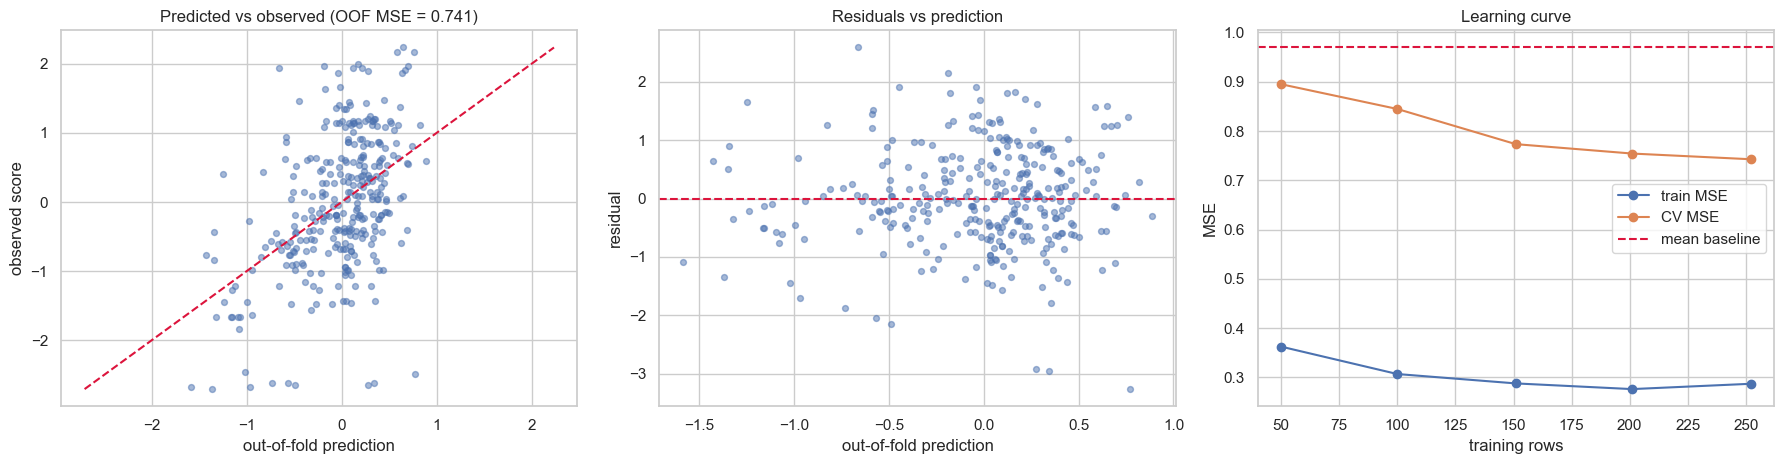

In [20]:
best_est = final.best_estimator_
oof = cross_val_predict(clone(best_est), X_raw, y, cv=KFold(5, shuffle=True, random_state=SEED))
resid = y - oof

sizes, tr_s, va_s = learning_curve(clone(best_est), X_raw, y, cv=KFold(5, shuffle=True, random_state=SEED),
                                   train_sizes=np.linspace(0.2, 1.0, 5), scoring="neg_mean_squared_error", n_jobs=-1)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
ax[0].scatter(oof, y, alpha=.5, s=18); lim = [min(oof.min(), y.min()), max(oof.max(), y.max())]
ax[0].plot(lim, lim, color="crimson", ls="--"); ax[0].set_xlabel("out-of-fold prediction"); ax[0].set_ylabel("observed score")
ax[0].set_title(f"Predicted vs observed (OOF MSE = {mean_squared_error(y, oof):.3f})")
ax[1].scatter(oof, resid, alpha=.5, s=18); ax[1].axhline(0, color="crimson", ls="--")
ax[1].set_xlabel("out-of-fold prediction"); ax[1].set_ylabel("residual"); ax[1].set_title("Residuals vs prediction")
ax[2].plot(sizes, -tr_s.mean(1), marker="o", label="train MSE"); ax[2].plot(sizes, -va_s.mean(1), marker="o", label="CV MSE")
ax[2].axhline(y.var(), color="crimson", ls="--", label="mean baseline"); ax[2].set_xlabel("training rows")
ax[2].set_ylabel("MSE"); ax[2].set_title("Learning curve"); ax[2].legend()
plt.tight_layout(); plt.show()

The predictions are shrunk towards the mean: the model cannot separate the extremes from this data, which is expected when R² is low. The residuals show no systematic pattern against the prediction, but a handful of students with very low observed scores (around −2.5 to −3) are never anticipated. In the learning curve the CV error is still edging down at 250 rows and has nearly levelled off, so more data would help only a little; the wide gap to the training curve is the price of the forest's flexibility (see the overfit ratio).

## 5.3 Predict the test set and save

Predictions summary: {'count': 79.0, 'mean': 0.103, 'std': 0.37, 'min': -0.785, '25%': -0.116, '50%': 0.084, '75%': 0.362, 'max': 0.865}


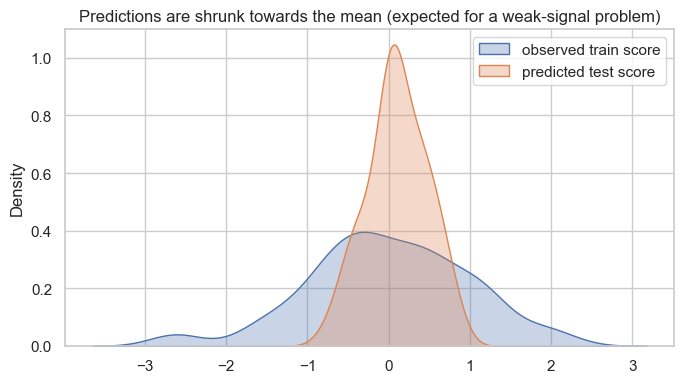

In [21]:
pred = final.predict(test)
print("Predictions summary:", pd.Series(pred).describe().round(3).to_dict())

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(y, ax=ax, label="observed train score", fill=True, alpha=.3)
sns.kdeplot(pred, ax=ax, label="predicted test score", fill=True, alpha=.3)
ax.set_title("Predictions are shrunk towards the mean (expected for a weak-signal problem)"); ax.legend()
plt.tight_layout(); plt.show()

The submission is a plain numeric vector written with R's `saveRDS`, so `readRDS(...)` returns a numeric vector of length 79. The code writes to `OUT_PATH`; change it to `predictions.rds` when you want to overwrite the submitted file.

In [22]:
OUT_PATH = "predictions_final_story.rds"

assert len(pred) == len(test) == 79 and np.isfinite(pred).all()
if shutil.which("Rscript"):
    with tempfile.NamedTemporaryFile("w", suffix=".csv", delete=False) as f:
        pd.Series(pred).to_csv(f, index=False, header=False); tmp = f.name
    subprocess.run(["Rscript", "-e", f"x <- scan('{tmp}', quiet=TRUE); saveRDS(as.numeric(x), '{OUT_PATH}')"], check=True)
    os.remove(tmp)
else:
    pyreadr.write_rds(OUT_PATH, pd.DataFrame({"pred": pred}))   # fallback: data frame, not a bare vector

check = pyreadr.read_r(OUT_PATH)[None]
print("Saved", OUT_PATH, "| read back shape:", np.asarray(check).shape)

Saved predictions_final_story.rds | read back shape: (79, 1)


## 5.4 Summary

* **Data:** weak signal, mostly linear, skewed `absences`; baseline MSE ≈ 0.97.
* **Preprocessing:** log/flag transform of `absences`, `had_failure`, `Medu × Fedu`, `alc_total`, one-hot encoding and scaling, all inside the CV pipeline. Derived features and their parents are never mixed in the plain-OLS hierarchical model (VIF).
* **Models:** baseline, penalised linear, hierarchical, KNN, tree, forest and boosting, all tuned with an inner CV and evaluated with an outer CV.
* **Result:** see `across` (Part 4.5); the selected model is `final_name`, with an expected test MSE close to its nested-CV MSE.
* **Caveat:** differences between the top few models are small compared with fold-to-fold variation; the choice of the single best one is therefore not sharply determined by the data.